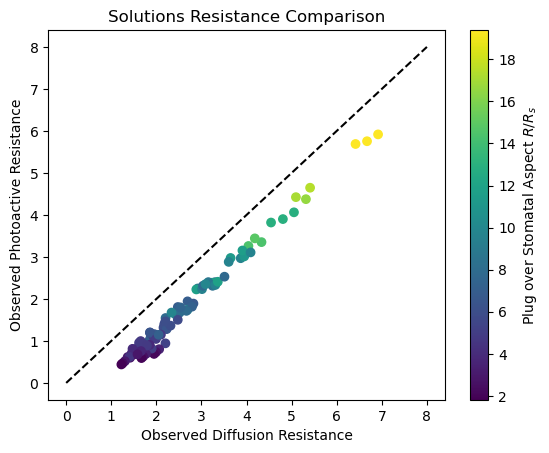

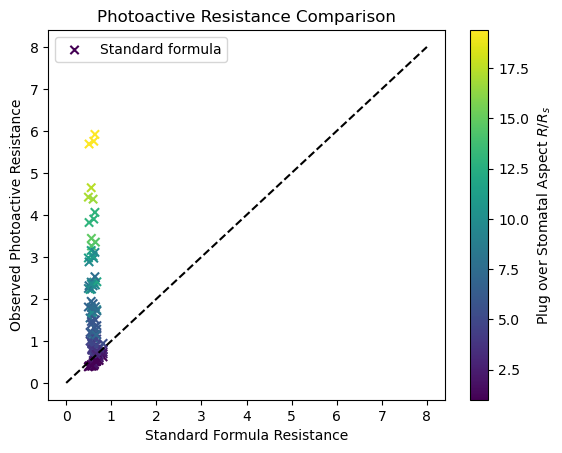

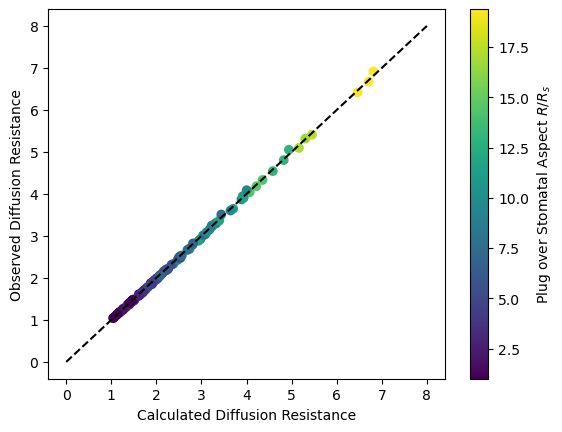

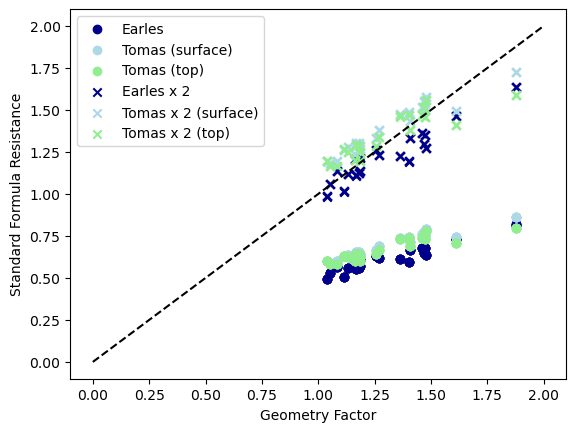

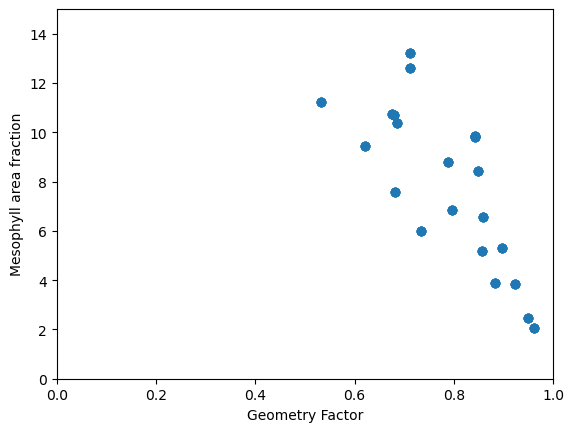

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd  
from mscthesis.core.io import load_dataframe 
from mscthesis.config import ProjectConfig 
from mscthesis.paths import ProjectPaths

config = ProjectConfig()
paths = ProjectPaths(config.behavior.storage_root)
df = load_dataframe(paths.diffusion_index.require())

df_diff = df[(df["solver"] == "diffusion")]
df_photo = df[(df["solver"] == "photoactive")]


# map geometry factor to sample id
df_geo = df_diff[["sample_id", "specifier", "plug_aspect", "stomatal_aspect", "porosity", "resistance"]]
# for each uniqe sample id, asign the geometry factor as resistance where specifier is 0 
sample_ids = df_geo["sample_id"].unique()
for sample_id in sample_ids:
    specifier_0 = df_geo[(df_geo["sample_id"] == sample_id) & (df_geo["specifier"] == 0)]
    if not specifier_0.empty:
        geometry_factor = specifier_0["resistance"].values[0]
        df_geo.loc[df_geo["sample_id"] == sample_id, "geometry_factor"] = geometry_factor

# make a new tortuosity_sim column as geometry_factor * porosity 
df_geo["tortuosity_sim"] = df_geo["geometry_factor"] * df_geo["porosity"]

# for all specifier 0, set stomatal_aspect to plug_aspect
df_geo.loc[df_geo["specifier"] == 0, "stomatal_aspect"] = df_geo.loc[df_geo["specifier"] == 0, "plug_aspect"]

# calculate the inlet resistance contribution
df_geo["inlet_resistance"] = 0.75 * df_geo["plug_aspect"] * (df_geo["plug_aspect"]/df_geo["stomatal_aspect"] - 1)

# calculate the total resistance as geometry_factor + inlet_resistance
df_geo["calculated_resistance"] = df_geo["geometry_factor"] + df_geo["inlet_resistance"]

df_geo["standard_formula_resistance"] = df_diff["surface_tortuosity_factor"] * df_diff["surface_lateral"] / df_diff["porosity"] / 2

# print(df_geo.head(6))

# CREATE PLOTS

# Show resistance diffusion against resistance photo
plt.scatter(df_diff["resistance"], df_photo["resistance"], c=df_diff["plug_aspect"]/df_diff["stomatal_aspect"], cmap="viridis")
plt.plot([0, 8], [0, 8], "k--")
plt.xlabel("Observed Diffusion Resistance")
plt.ylabel("Observed Photoactive Resistance")
plt.title("Solutions Resistance Comparison")
plt.colorbar(label=r"Plug over Stomatal Aspect $R/R_s$")
plt.show()


# Show standard formula for photoactive resistance against observed photoactive resistance
plt.scatter(df_geo["standard_formula_resistance"], df_photo["resistance"], c=df_geo["plug_aspect"]/df_geo["stomatal_aspect"], cmap="viridis", marker="x", label="Standard formula")
plt.plot([0, 8], [0, 8], "k--")
plt.xlabel("Standard Formula Resistance")
plt.ylabel("Observed Photoactive Resistance")
plt.title("Photoactive Resistance Comparison")
plt.colorbar(label=r"Plug over Stomatal Aspect $R/R_s$")
plt.legend()
plt.show()

# Show calculated resistance against observed diffusion resistance
plt.scatter(df_geo["calculated_resistance"], df_geo["resistance"], c=df_geo["plug_aspect"]/df_geo["stomatal_aspect"], cmap="viridis")
plt.plot([0, 8], [0, 8], "k--")
plt.xlabel("Calculated Diffusion Resistance")
plt.ylabel("Observed Diffusion Resistance")
plt.colorbar(label=r"Plug over Stomatal Aspect $R/R_s$")
plt.show()

# Show geometry factor against Earles et al 2018
plt.scatter(df_geo["geometry_factor"], df_geo["standard_formula_resistance"], label="Earles", color="darkblue")
plt.scatter(df_geo["geometry_factor"], df_diff["surface_tortuosity_factor"]/df_geo["porosity"]/2, label="Tomas (surface)", color="lightblue")
plt.scatter(df_geo["geometry_factor"], df_diff["top_tortuosity_factor"]/df_geo["porosity"]/2, label="Tomas (top)", color="lightgreen")
plt.scatter(df_geo["geometry_factor"], df_geo["standard_formula_resistance"]*2, label="Earles x 2", marker="x", color="darkblue")
plt.scatter(df_geo["geometry_factor"], df_diff["surface_tortuosity_factor"]/df_geo["porosity"], label="Tomas x 2 (surface)", marker="x", color="lightblue")
plt.scatter(df_geo["geometry_factor"], df_diff["top_tortuosity_factor"]/df_geo["porosity"], label="Tomas x 2 (top)", marker="x", color="lightgreen")
plt.plot([0, 2], [0, 2], "k--")
plt.xlabel("Geometry Factor")
plt.ylabel("Standard Formula Resistance")
plt.legend()
plt.show()


# Show representation in trait space
plt.scatter(1/df_geo["geometry_factor"], df_photo["mesophyll_area_fraction"])
plt.xlabel("Geometry Factor")
plt.ylabel("Mesophyll area fraction")
plt.xlim(0, 1.0)
plt.ylim(0, 15.0)
plt.show()

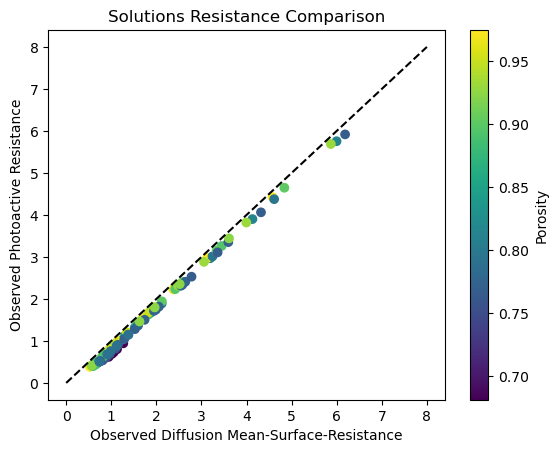

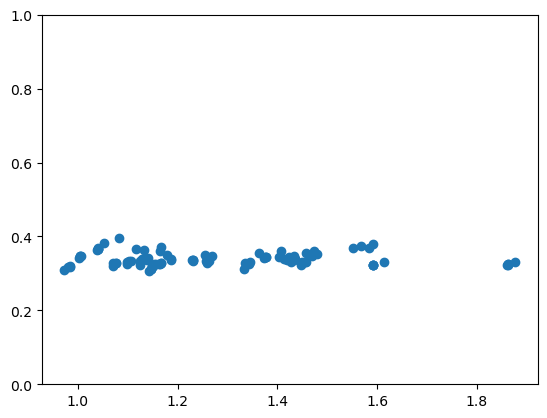

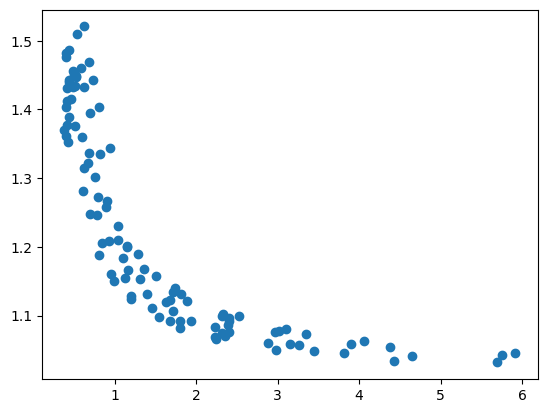

In [2]:
experiment = np.abs((df_diff["substomatal_mean"] - df_diff["mesophyll_mean"])/df_diff["top_flux_grad"] * df_diff["plug_area"])

plt.scatter(experiment, df_photo["resistance"], c=df_diff["porosity"], cmap="viridis")
plt.plot([0, 8], [0, 8], "k--")
plt.xlabel("Observed Diffusion Mean-Surface-Resistance")
plt.ylabel("Observed Photoactive Resistance")
plt.title("Solutions Resistance Comparison")
plt.colorbar(label=r"Porosity")
plt.show()

# for all specifier 0, set stomatal_aspect to plug_aspect
df_photo.loc[df_photo["specifier"] == 0, "stomatal_aspect"] = df_photo.loc[df_photo["specifier"] == 0, "plug_aspect"]

off_set_diff = df_diff["resistance"] - df_geo["inlet_resistance"]
off_set_photo = df_photo["resistance"] -  0.75 * df_photo["plug_aspect"] * (df_photo["plug_aspect"]/df_photo["stomatal_aspect"] - 1)

plt.scatter(off_set_diff, off_set_photo.values / off_set_diff.values)
plt.ylim(0, 1.0)
plt.show()

plt.scatter(df_photo["resistance"], experiment.values / df_photo["resistance"].values)